# Pantheon+SH0ES — emcee vs MultiNest & Model Comparison

This notebook:
1. Compares posterior parameter estimates from **emcee** and **MultiNest**
2. Compares cosmological models using **AIC**, **BIC**, and **Bayes factors** (log Z from MultiNest)

Load chains from both `pantheon_inference.ipynb` (emcee) and `pantheon_multinest.ipynb` (MultiNest).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner
import json
import os
from astropy.cosmology import FlatLambdaCDM, LambdaCDM, FlatwCDM, Flatw0waCDM
import astropy.units as u

os.makedirs('plots', exist_ok=True)

M_fixed = -19.253   # Riess et al. 2022 / SH0ES (arXiv:2112.04510)

# Load data
data = '/Users/edwinperez/Documents/Work/advanced_lab/topic2_pantheon_plus/data'
df   = pd.read_csv(f'{data}/Pantheon+SH0ES.dat', sep=r'\s+', comment='#')
mask = (df['zHD'] > 0.01) & (df['IS_CALIBRATOR'] == 0)
df   = df[mask].reset_index(drop=True)
z    = df['zHD'].values
mB   = df['mB'].values;  x1 = df['x1'].values;  c = df['c'].values
mB_err = df['mBERR'].values; x1_err = df['x1ERR'].values; c_err = df['cERR'].values
N    = len(z)
print(f'SNe: {N}')

SNe: 1580


## 1. Load all chains

In [2]:
MODELS = ['Flat LCDM', 'Curved LCDM', 'Flat wCDM', 'Flat w0waCDM']
COLORS = {'Flat LCDM': 'C0', 'Curved LCDM': 'C1', 'Flat wCDM': 'C2', 'Flat w0waCDM': 'C3'}

# Parameter labels per model (without M — it is fixed)
LABELS = {
    'Flat LCDM'   : [r'$H_0$', r'$\Omega_m$', r'$\alpha$', r'$\beta$'],
    'Curved LCDM' : [r'$H_0$', r'$\Omega_m$', r'$\Omega_k$', r'$\alpha$', r'$\beta$'],
    'Flat wCDM'   : [r'$H_0$', r'$\Omega_m$', r'$w$', r'$\alpha$', r'$\beta$'],
    'Flat w0waCDM': [r'$H_0$', r'$\Omega_m$', r'$w_0$', r'$w_a$', r'$\alpha$', r'$\beta$'],
}
N_COSMO = {'Flat LCDM': 2, 'Curved LCDM': 3, 'Flat wCDM': 3, 'Flat w0waCDM': 4}

# emcee chains (from pantheon_inference.ipynb)
emcee_chains_path = '/Users/edwinperez/Documents/Work/advanced_lab/topic2_pantheon_plus/chains/'
emcee_chains = {
    'Flat LCDM'   : np.load(f'{emcee_chains_path}/flat_lcdm.npy'),
    'Curved LCDM' : np.load(f'{emcee_chains_path}/curved_lcdm.npy'),
    'Flat wCDM'   : np.load(f'{emcee_chains_path}/flat_wcdm.npy'),
    'Flat w0waCDM': np.load(f'{emcee_chains_path}/flat_w0wa.npy'),
}

# MultiNest chains (from pantheon_multinest.ipynb)
mn_chains = {
    m: np.load(f'chains/mn_{m.replace(" ","_")}.npy') for m in MODELS
}

# MultiNest evidence
with open('chains/mn_evidence.json') as f:
    evidence = json.load(f)

for m in MODELS:
    print(f'{m:15s}  emcee: {emcee_chains[m].shape[0]:6d}  MN: {mn_chains[m].shape[0]:6d}')

Flat LCDM        emcee:  36160  MN:   1957
Curved LCDM      emcee:  31552  MN:   2070
Flat wCDM        emcee:  19264  MN:   2114
Flat w0waCDM     emcee:   7552  MN:   2250


## 2. AIC and BIC model comparison

For model comparison we need the **maximum log-likelihood** $\ln\mathcal{L}_{\rm max}$ and number of free parameters $k$:

$$\text{AIC} = 2k - 2\ln\mathcal{L}_{\rm max}$$
$$\text{BIC} = k\ln N - 2\ln\mathcal{L}_{\rm max}$$

Lower AIC/BIC = preferred model. $\Delta$AIC or $\Delta$BIC > 10 = strong evidence against.

In [3]:
# Redefine likelihood with full covariance for AIC/BIC calculation
with open(f'{data}/Pantheon+SH0ES_STATONLY.cov') as f:
    N_cov = int(f.readline())
    C_full = np.array(f.read().split(), dtype=float).reshape(N_cov, N_cov)
orig_mask = (pd.read_csv(f'{data}/Pantheon+SH0ES.dat', sep=r'\s+', comment='#')
             .pipe(lambda d: (d['zHD']>0.01)&(d['IS_CALIBRATOR']==0)).values)
idx  = np.where(orig_mask)[0]
C    = C_full[np.ix_(idx, idx)]
C_inv = np.linalg.inv(C)
sign, logdet = np.linalg.slogdet(2 * np.pi * C)

def mu_th(name, theta_cosmo):
    H0, Om0 = theta_cosmo[0], theta_cosmo[1]
    if name == 'Flat LCDM':    cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    elif name == 'Curved LCDM': cosmo = LambdaCDM(H0=H0, Om0=Om0, Ode0=1-Om0-theta_cosmo[2])
    elif name == 'Flat wCDM':   cosmo = FlatwCDM(H0=H0, Om0=Om0, w0=theta_cosmo[2])
    elif name == 'Flat w0waCDM': cosmo = Flatw0waCDM(H0=H0, Om0=Om0, w0=theta_cosmo[2], wa=theta_cosmo[3])
    return 5*np.log10(cosmo.luminosity_distance(z).to(u.Mpc).value) + 25

def loglike(name, theta):
    nc     = N_COSMO[name]
    alpha, beta = theta[nc], theta[nc+1]
    mu_o   = mB + alpha*x1 - beta*c - M_fixed
    mu_t   = mu_th(name, theta[:nc])
    delta  = mu_o - mu_t
    return -0.5 * (delta @ C_inv @ delta + logdet)

# Number of free parameters per model
K = {'Flat LCDM': 4, 'Curved LCDM': 5, 'Flat wCDM': 5, 'Flat w0waCDM': 6}

print(f'\n{"Model":15s}  {"k":>4}  {"ln L_max":>12}  {"AIC":>10}  {"BIC":>10}  {"ΔAIC":>8}  {"ΔBIC":>8}')
print('-'*75)

aic_dict, bic_dict, lmax_dict = {}, {}, {}
for name, chain in emcee_chains.items():
    # Max likelihood from the chain (best sample)
    lls    = np.array([loglike(name, s) for s in chain[::10]])  # subsample for speed
    lmax   = lls.max()
    k      = K[name]
    aic    = 2*k - 2*lmax
    bic    = k*np.log(N) - 2*lmax
    aic_dict[name], bic_dict[name], lmax_dict[name] = aic, bic, lmax

aic_ref = aic_dict['Flat LCDM']
bic_ref = bic_dict['Flat LCDM']
for name in MODELS:
    print(f'{name:15s}  {K[name]:>4}  {lmax_dict[name]:>12.2f}  {aic_dict[name]:>10.2f}  '
          f'{bic_dict[name]:>10.2f}  {aic_dict[name]-aic_ref:>+8.2f}  {bic_dict[name]-bic_ref:>+8.2f}')


Model               k      ln L_max         AIC         BIC      ΔAIC      ΔBIC
---------------------------------------------------------------------------
Flat LCDM           4        705.17    -1402.34    -1380.88     +0.00     +0.00
Curved LCDM         5        703.92    -1397.83    -1371.01     +4.50     +9.87
Flat wCDM           5        705.56    -1401.12    -1374.29     +1.22     +6.59
Flat w0waCDM        6        704.31    -1396.63    -1364.44     +5.71    +16.44


## 3. Bayes factors from MultiNest

MultiNest computes the Bayesian evidence $\mathcal{Z} = \int \mathcal{L}(\theta)\pi(\theta)d\theta$.
The **Bayes factor** $B_{ij} = \mathcal{Z}_i/\mathcal{Z}_j$ quantifies relative model preference.

Jeffreys scale: $|\Delta\ln Z| < 1$ = inconclusive, 1–2.5 = moderate, 2.5–5 = strong, >5 = decisive.

In [4]:
ref_logZ = evidence['Flat LCDM']
print(f'\n{"Model":15s}  {"log Z":>10}  {"Δlog Z":>10}  {"Jeffreys"}' )
print('-'*55)

def jeffreys(dlnZ):
    a = abs(dlnZ)
    if a < 1:   return 'Inconclusive'
    if a < 2.5: return 'Moderate'
    if a < 5:   return 'Strong'
    return 'Decisive'

for name in MODELS:
    dlnZ = evidence[name] - ref_logZ
    print(f'{name:15s}  {evidence[name]:>10.2f}  {dlnZ:>+10.2f}  {jeffreys(dlnZ)}')


Model                 log Z      Δlog Z  Jeffreys
-------------------------------------------------------
Flat LCDM            742.19       +0.00  Inconclusive
Curved LCDM          744.37       +2.18  Moderate
Flat wCDM            744.00       +1.80  Moderate
Flat w0waCDM         744.33       +2.13  Moderate


## 4. emcee vs MultiNest — parameter comparison

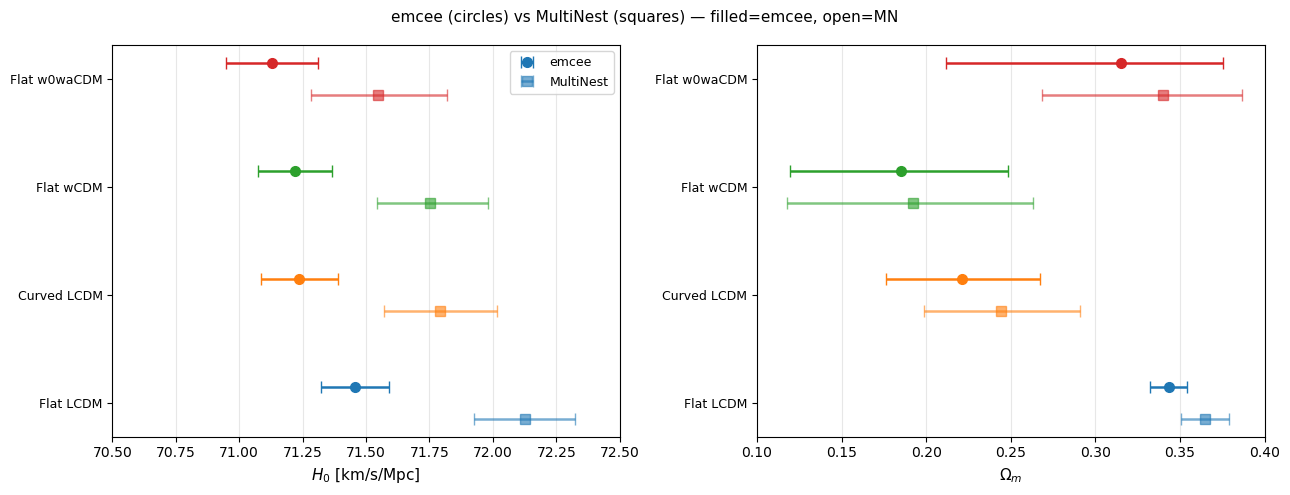

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, pidx, plbl, xlo, xhi in [
    (axes[0], 0, r'$H_0$ [km/s/Mpc]', 70.5, 72.5),
    (axes[1], 1, r'$\Omega_m$',         0.1, 0.4),
]:
    y_pos = np.arange(len(MODELS))
    for k, name in enumerate(MODELS):
        col = COLORS[name]
        # emcee
        p16, p50, p84 = np.percentile(emcee_chains[name][:, pidx], [16, 50, 84])
        ax.errorbar(p50, k+0.15, xerr=[[p50-p16],[p84-p50]],
                    fmt='o', color=col, ms=7, capsize=4, lw=1.8,
                    label='emcee' if k==0 else '')
        # MultiNest
        p16, p50, p84 = np.percentile(mn_chains[name][:, pidx], [16, 50, 84])
        ax.errorbar(p50, k-0.15, xerr=[[p50-p16],[p84-p50]],
                    fmt='s', color=col, ms=7, capsize=4, lw=1.8, alpha=0.6,
                    label='MultiNest' if k==0 else '')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(MODELS, fontsize=9)
    ax.set_xlabel(plbl, fontsize=11)
    ax.set_xlim(xlo, xhi)
    ax.grid(axis='x', alpha=0.3)
    if pidx == 0:
        ax.legend(fontsize=9)

plt.suptitle('emcee (circles) vs MultiNest (squares) — filled=emcee, open=MN', fontsize=11)
plt.tight_layout()
plt.savefig('plots/emcee_vs_mn.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Overlaid posteriors — emcee vs MultiNest for each model

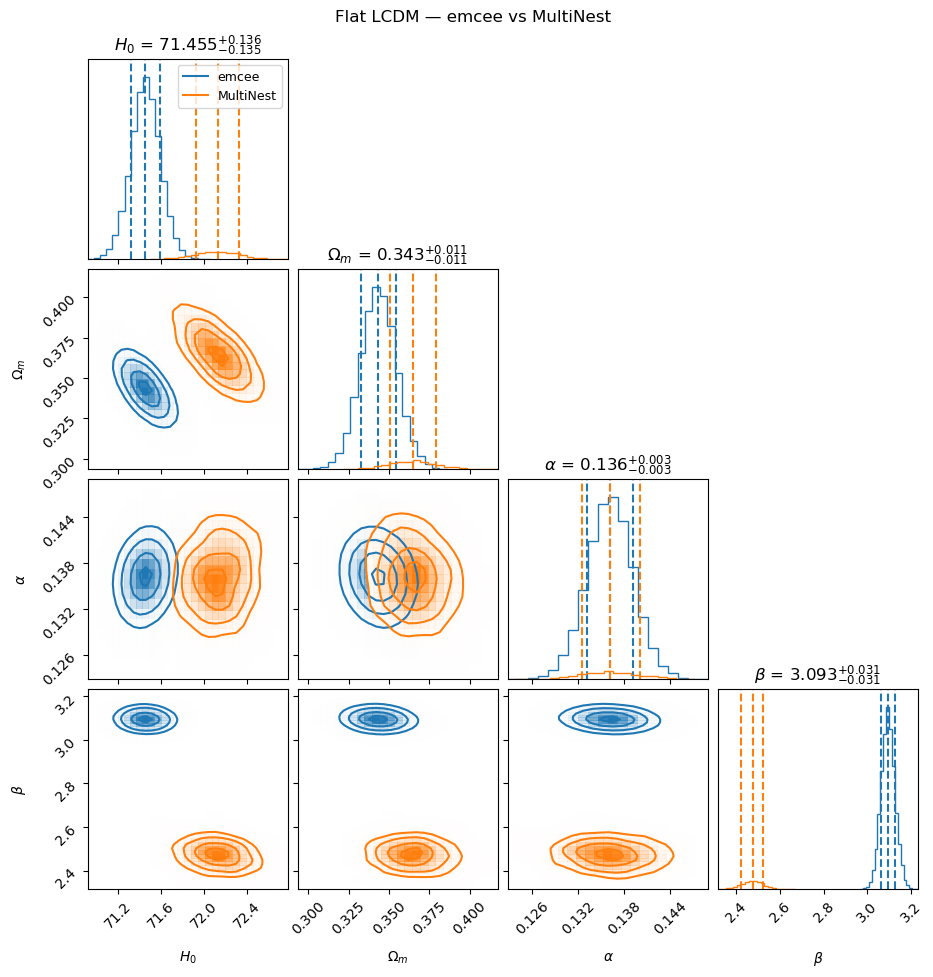

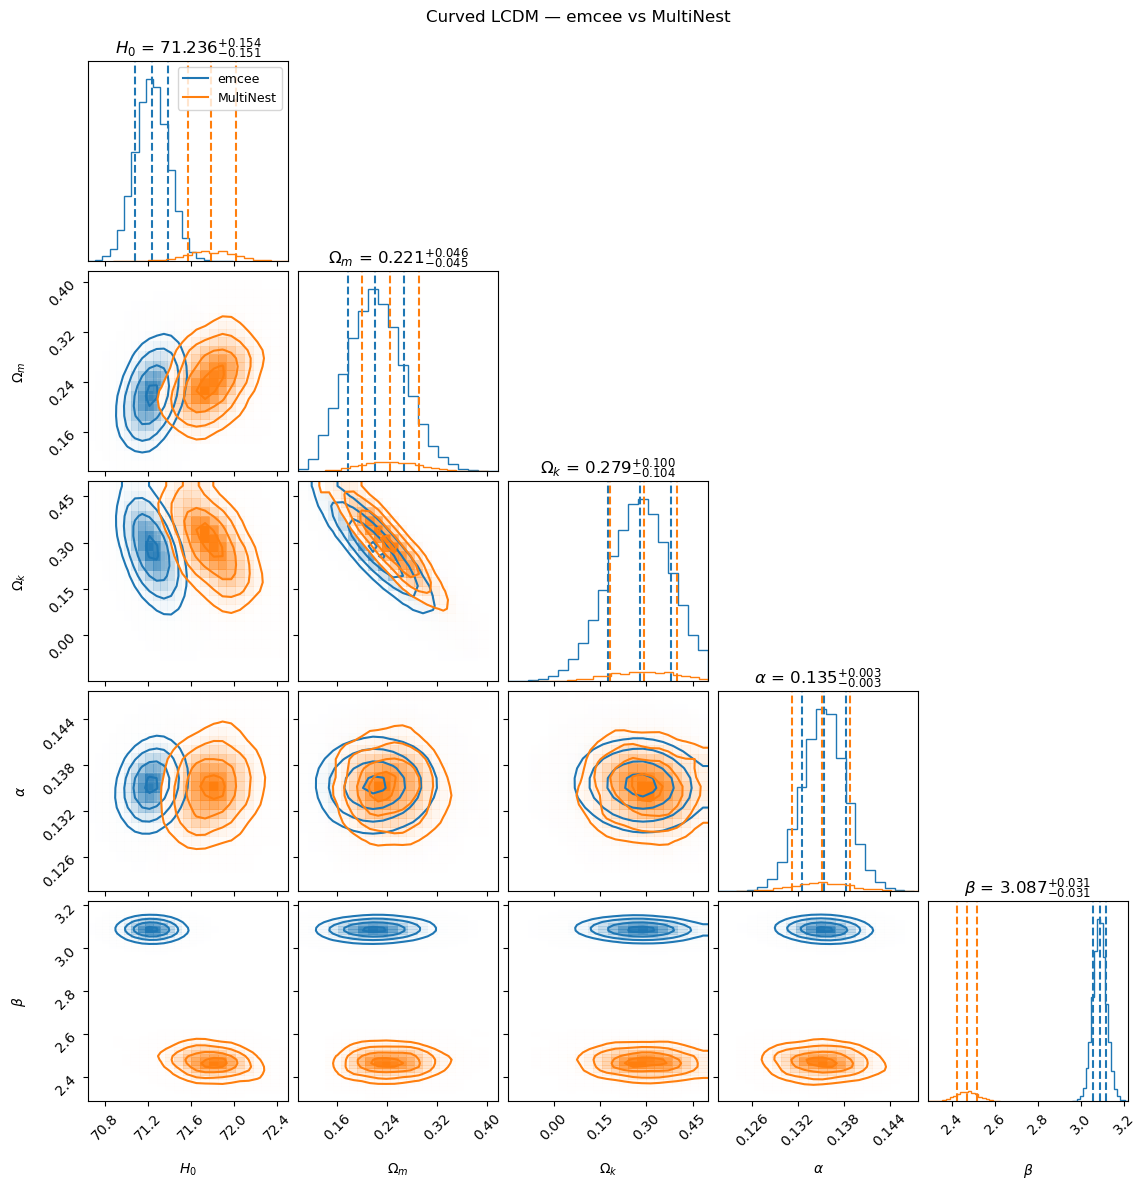

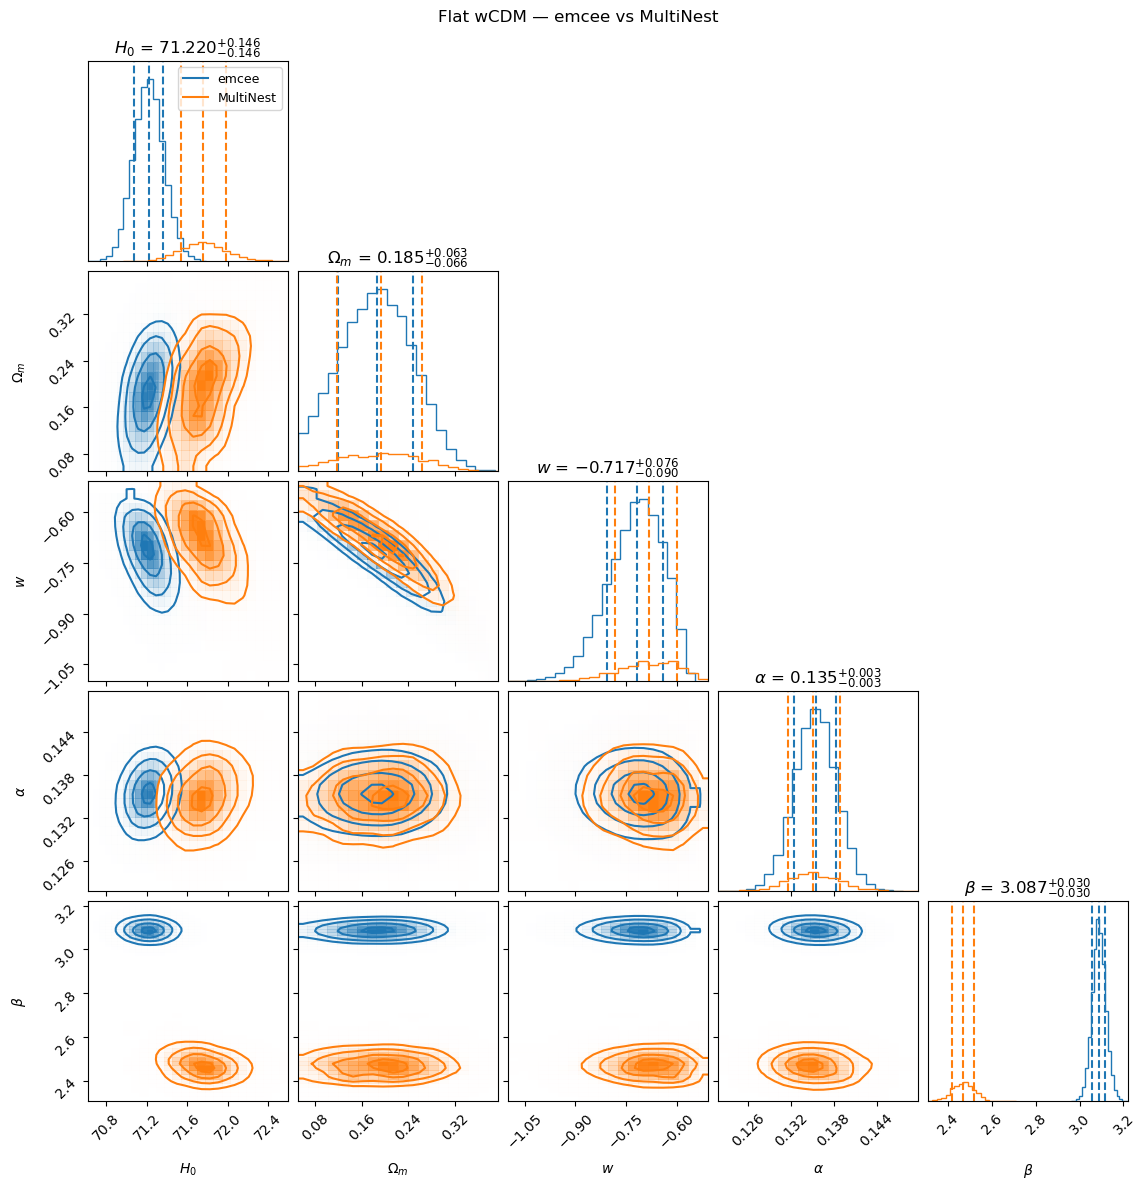

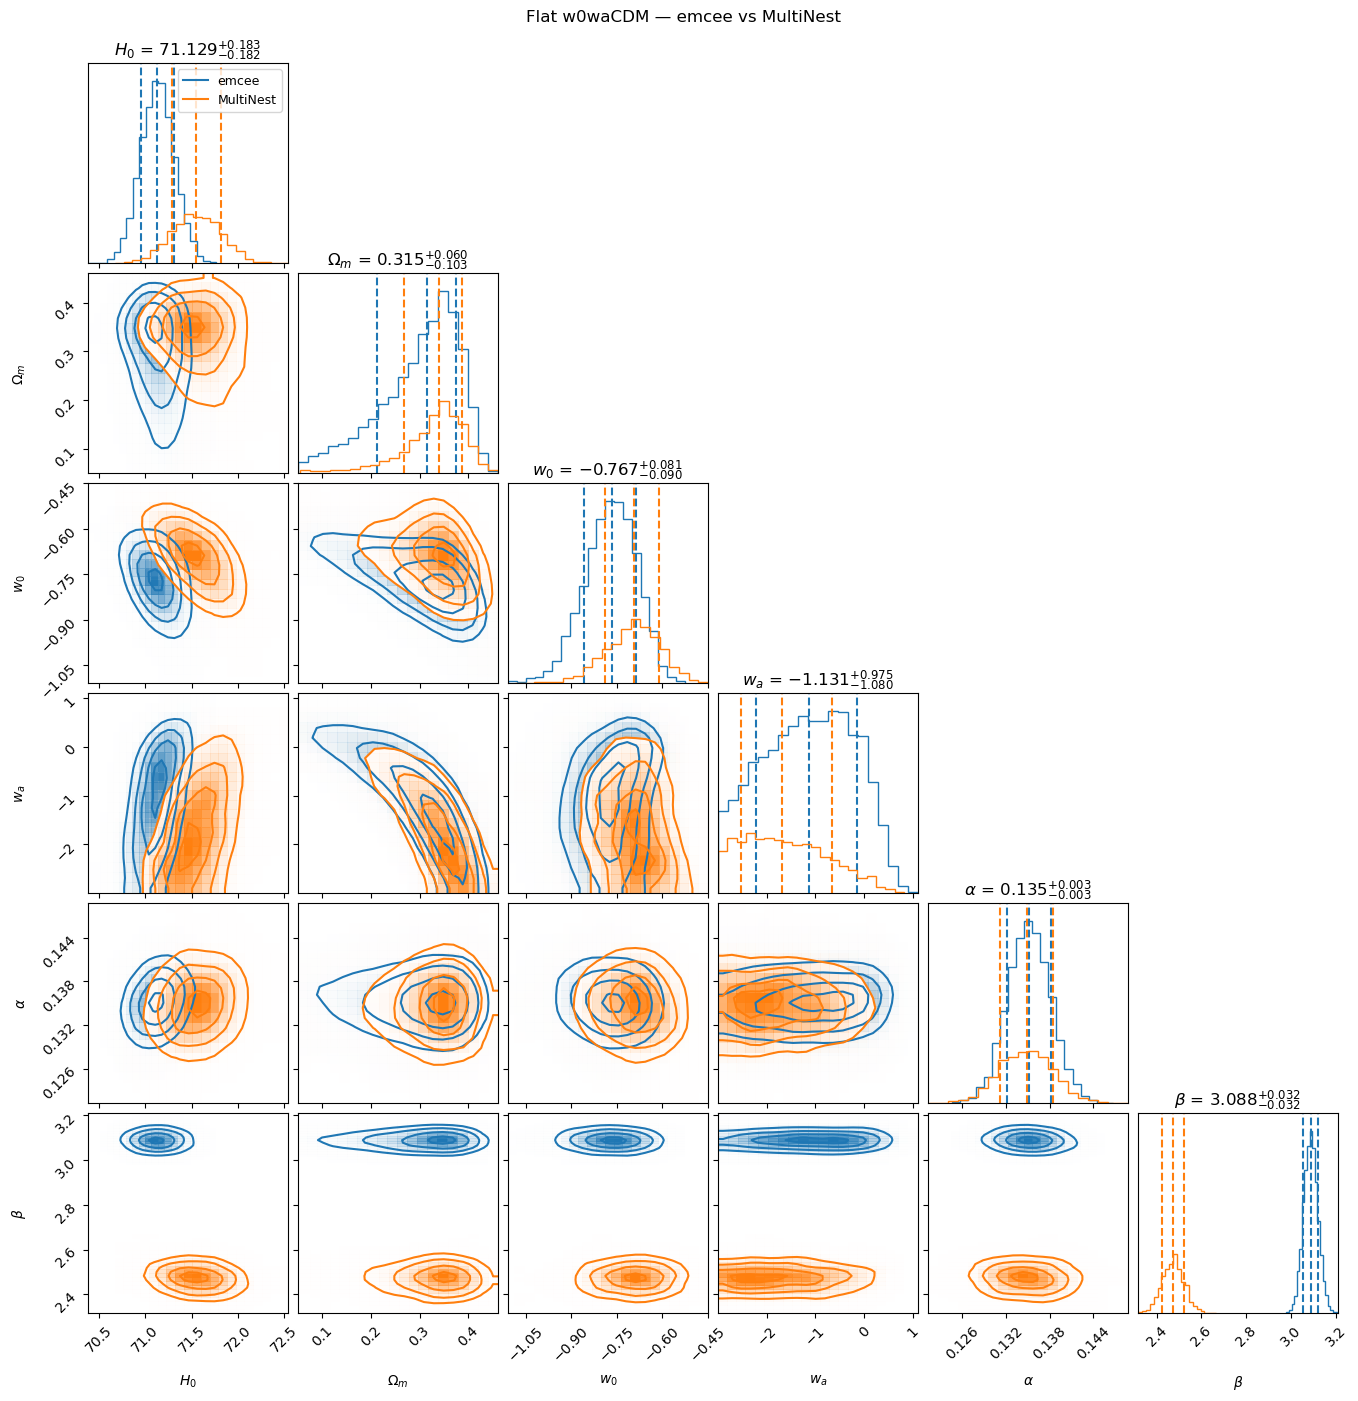

In [8]:
for name in MODELS:
    lbls = LABELS[name]
    fig  = corner.corner(emcee_chains[name], labels=lbls, color='C0',
                         quantiles=[0.16,0.5,0.84], show_titles=True,
                         plot_datapoints=False, smooth=1.0, title_fmt='.3f')
    corner.corner(mn_chains[name], labels=lbls, color='C1',
                  quantiles=[0.16,0.5,0.84], show_titles=False,
                  plot_datapoints=False, smooth=1.0, fig=fig)
    # Manual legend
    fig.axes[0].plot([], color='C0', label='emcee')
    fig.axes[0].plot([], color='C1', label='MultiNest')
    fig.axes[0].legend(fontsize=9, loc='upper right')
    fig.suptitle(f'{name} — emcee vs MultiNest', y=1.01, fontsize=12)
    fig.savefig(f'plots/overlay_{name.replace(" ","_")}.png', dpi=110, bbox_inches='tight')
    plt.show()

## 6. Hubble diagram — all models, MultiNest medians

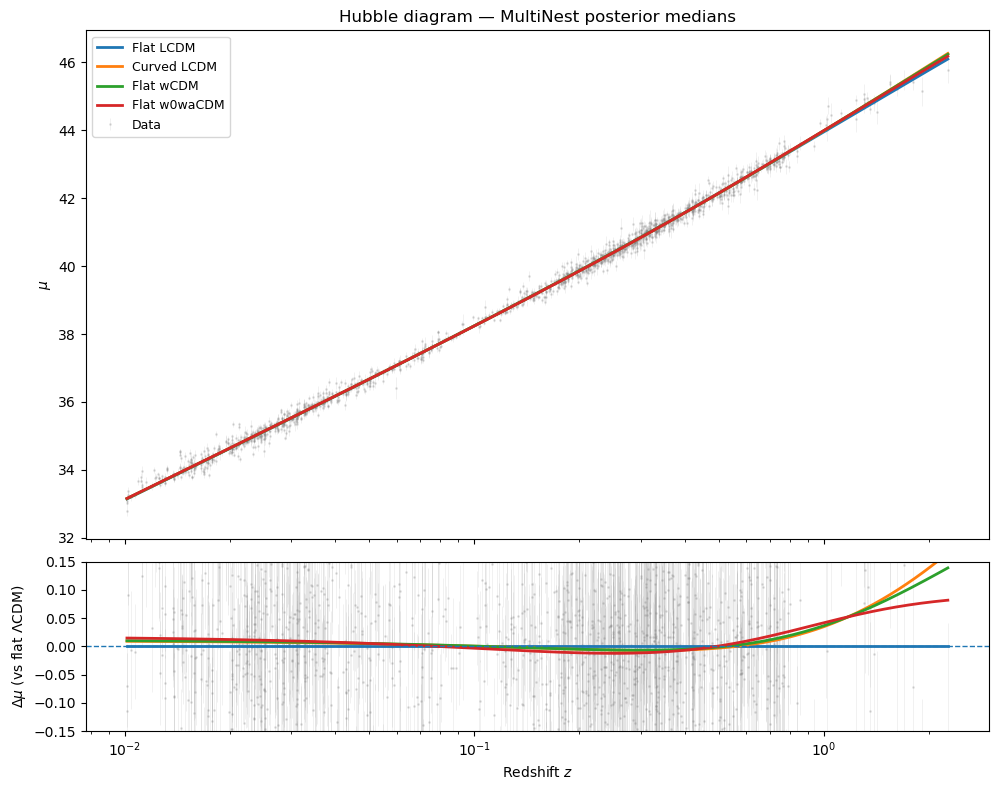

In [9]:
z_th    = np.geomspace(z.min(), z.max(), 400)
med_ref = np.median(mn_chains['Flat LCDM'], axis=0)
a_med, b_med = med_ref[2], med_ref[3]
mu_o_plot = mB + a_med*x1 - b_med*c - M_fixed
sig_plot  = np.sqrt(mB_err**2 + (a_med*x1_err)**2 + (b_med*c_err)**2)
mu_ref_z  = mu_th('Flat LCDM', med_ref)

fig, axes = plt.subplots(2, 1, figsize=(10, 8),
                          gridspec_kw={'height_ratios':[3,1]}, sharex=True)
ax, ax_res = axes
ax.errorbar(z, mu_o_plot, yerr=sig_plot, fmt='.', color='gray',
            alpha=0.2, ms=2, elinewidth=0.4, capsize=0, label='Data', zorder=1)

for name in MODELS:
    nc   = N_COSMO[name]
    med  = np.median(mn_chains[name], axis=0)
    mu_c = mu_th(name, med[:nc])
    mu_c_th = np.array([mu_th(name, med[:nc])[i] for i in range(N)])  # at data z
    # compute at z_th
    H0, Om0 = med[0], med[1]
    if name=='Flat LCDM':    cosmo=FlatLambdaCDM(H0=H0,Om0=Om0)
    elif name=='Curved LCDM': cosmo=LambdaCDM(H0=H0,Om0=Om0,Ode0=1-Om0-med[2])
    elif name=='Flat wCDM':   cosmo=FlatwCDM(H0=H0,Om0=Om0,w0=med[2])
    elif name=='Flat w0waCDM': cosmo=Flatw0waCDM(H0=H0,Om0=Om0,w0=med[2],wa=med[3])
    mu_line = 5*np.log10(cosmo.luminosity_distance(z_th).to(u.Mpc).value)+25
    mu_ref_th = 5*np.log10(FlatLambdaCDM(H0=med_ref[0],Om0=med_ref[1])
                           .luminosity_distance(z_th).to(u.Mpc).value)+25
    ax.plot(z_th, mu_line, color=COLORS[name], lw=2, label=name)
    ax_res.plot(z_th, mu_line - mu_ref_th, color=COLORS[name], lw=2)

ax_res.errorbar(z, mu_o_plot - mu_ref_z, yerr=sig_plot, fmt='.', color='gray',
                alpha=0.2, ms=2, elinewidth=0.4, capsize=0, zorder=1)
ax_res.axhline(0, color='C0', lw=1, ls='--')
ax_res.set_ylabel(r'$\Delta\mu$ (vs flat ΛCDM)'); ax_res.set_xlabel('Redshift $z$')
ax_res.set_ylim(-0.15, 0.15); ax_res.set_xscale('log')
ax.set_ylabel(r'$\mu$'); ax.set_xscale('log')
ax.set_title('Hubble diagram — MultiNest posterior medians')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plots/mn_hubble_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Summary: AIC, BIC, Bayes factors

In [10]:
print(f'\n{"Model":15s}  {"k":>3}  {"ln L_max":>10}  {"AIC":>8}  {"ΔAIC":>7}  {"BIC":>8}  {"ΔBIC":>7}  {"Δln Z":>8}  {"Jeffreys"}')
print('-'*95)
for name in MODELS:
    dlnZ = evidence[name] - ref_logZ
    print(f'{name:15s}  {K[name]:>3}  {lmax_dict[name]:>10.2f}  '
          f'{aic_dict[name]:>8.2f}  {aic_dict[name]-aic_ref:>+7.2f}  '
          f'{bic_dict[name]:>8.2f}  {bic_dict[name]-bic_ref:>+7.2f}  '
          f'{dlnZ:>+8.2f}  {jeffreys(dlnZ)}')

print('\nNote: ΔAIC/ΔBIC relative to Flat ΛCDM (reference model).')
print('      Δln Z: positive = preferred over Flat ΛCDM.')


Model              k    ln L_max       AIC     ΔAIC       BIC     ΔBIC     Δln Z  Jeffreys
-----------------------------------------------------------------------------------------------
Flat LCDM          4      705.17  -1402.34    +0.00  -1380.88    +0.00     +0.00  Inconclusive
Curved LCDM        5      703.92  -1397.83    +4.50  -1371.01    +9.87     +2.18  Moderate
Flat wCDM          5      705.56  -1401.12    +1.22  -1374.29    +6.59     +1.80  Moderate
Flat w0waCDM       6      704.31  -1396.63    +5.71  -1364.44   +16.44     +2.13  Moderate

Note: ΔAIC/ΔBIC relative to Flat ΛCDM (reference model).
      Δln Z: positive = preferred over Flat ΛCDM.
